# Wireless Autoencoder with Rayleigh Fading
This notebook extends the basic AWGN autoencoder by adding a multiplicative Rayleigh fading channel and providing the receiver with perfect Channel State Information (CSI).

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Define the Communication Autoencoder with Rayleigh Fading
class WirelessAutoencoderFading(nn.Module):
    def __init__(self, M, n_channel_dims):
        super(WirelessAutoencoderFading, self).__init__()
        self.M = M
        self.n_dims = n_channel_dims
        
        # Transmitter (Encoder)
        self.encoder = nn.Sequential(
            nn.Linear(self.M, self.M),
            nn.ReLU(),
            nn.Linear(self.M, self.n_dims) 
        )
        
        # Receiver (Decoder)
        # Input is now n_dims (the received signal r) + 1 (the fading coefficient h)
        self.decoder = nn.Sequential(
            nn.Linear(self.n_dims + 1, self.M),
            nn.ReLU(),
            nn.Linear(self.M, self.M)
        )
        
    def forward(self, x, noise_variance):
        # 1. Encode message to channel symbols
        s = self.encoder(x)
        
        # 2. Normalization layer (Energy constraint: average power = 1)
        s_norm = np.sqrt(self.n_dims) * (s / torch.norm(s, p=2, dim=1, keepdim=True))
        
        # 3. Channel Layer: Rayleigh Fading + AWGN
        # Generate Rayleigh fading coefficient h for each batch sample
        # A Rayleigh random variable can be generated from two independent standard normal variables
        h = torch.sqrt(torch.randn(s_norm.size(0), 1, device=x.device)**2 + \
                       torch.randn(s_norm.size(0), 1, device=x.device)**2) / np.sqrt(2)
        
        # Multiplicative fading
        faded_signal = h * s_norm
        
        # Additive noise
        noise = torch.randn_like(s_norm) * np.sqrt(noise_variance)
        r = faded_signal + noise
        
        # 4. Decode received symbols back to message probabilities
        # The receiver is given perfect CSI, so it knows h
        decoder_input = torch.cat([r, h], dim=1)
        y = self.decoder(decoder_input)
        
        return y, s_norm, r, h


In [2]:
# System Parameters
M = 16       # 16 possible messages
n_dims = 2   # 2 channel dimensions (I and Q)
NUM_SAMPLES = 80000
BATCH_SIZE = 1024
EPOCHS = 60  # slightly more epochs as fading is harder to learn

random_labels = torch.randint(0, M, (NUM_SAMPLES,))
data_onehot = torch.nn.functional.one_hot(random_labels, num_classes=M).float()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = WirelessAutoencoderFading(M, n_dims).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

training_noise_var = 0.05 

print("Starting Training...")
model.train()
for epoch in range(EPOCHS):
    permutation = torch.randperm(data_onehot.size(0))
    epoch_loss = 0
    
    for i in range(0, data_onehot.size(0), BATCH_SIZE):
        indices = permutation[i:i+BATCH_SIZE]
        batch_x = data_onehot[indices].to(device)
        batch_y_labels = random_labels[indices].to(device)
        
        optimizer.zero_grad()
        outputs, _, _, _ = model(batch_x, training_noise_var)
        loss = criterion(outputs, batch_y_labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss/(NUM_SAMPLES/BATCH_SIZE):.4f}")
print("Training Complete!")


Starting Training...
Epoch [5/60], Loss: 0.9518
Epoch [10/60], Loss: 0.9104
Epoch [15/60], Loss: 0.8939
Epoch [20/60], Loss: 0.8937
Epoch [25/60], Loss: 0.8823
Epoch [30/60], Loss: 0.8737
Epoch [35/60], Loss: 0.8710
Epoch [40/60], Loss: 0.8697
Epoch [45/60], Loss: 0.8754
Epoch [50/60], Loss: 0.8723
Epoch [55/60], Loss: 0.8701
Epoch [60/60], Loss: 0.8635
Training Complete!


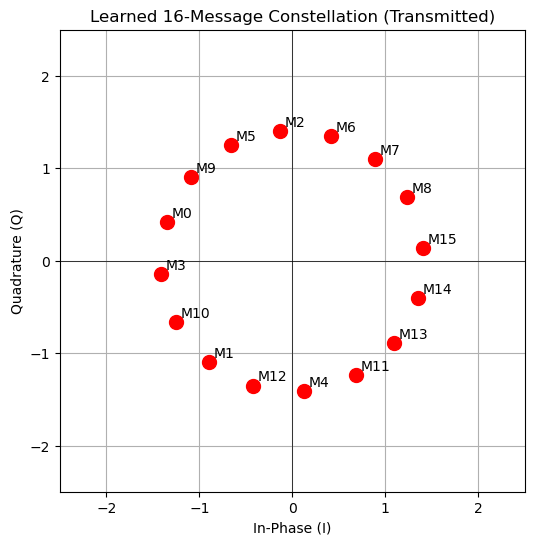

In [3]:
model.eval()
with torch.no_grad():
    test_identity = torch.eye(M).to(device)
    # We want to see the transmitted constellation without noise or fading for the plot
    # But the model generates random fading internally. We can just look at s_norm.
    _, transmitted_symbols, received_symbols, _ = model(test_identity, noise_variance=0)
    transmitted_symbols = transmitted_symbols.cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(transmitted_symbols[:, 0], transmitted_symbols[:, 1], color='red', marker='o', s=100)
for i in range(M):
    plt.annotate(f"M{i}", (transmitted_symbols[i, 0]+0.05, transmitted_symbols[i, 1]+0.05))
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("Learned 16-Message Constellation (Transmitted)")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.show()


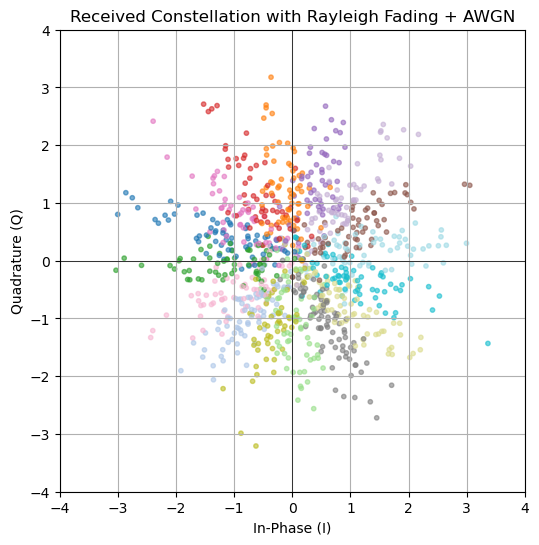

In [4]:
# Plot the received constellation with fading and noise
model.eval()
with torch.no_grad():
    # Send 1000 random messages to see the received scatter plot
    test_labels = torch.randint(0, M, (1000,))
    test_data = torch.nn.functional.one_hot(test_labels, num_classes=M).float().to(device)
    _, _, r, _ = model(test_data, noise_variance=0.05) # 0.05 variance noise
    r = r.cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(r[:, 0], r[:, 1], c=test_labels.numpy(), cmap='tab20', alpha=0.6, s=10)
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("Received Constellation with Rayleigh Fading + AWGN")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.show()


Evaluating BLER performance...
Eb/N0 (dB): -4 | BLER: 0.75620
Eb/N0 (dB): -3 | BLER: 0.72356
Eb/N0 (dB): -2 | BLER: 0.70088
Eb/N0 (dB): -1 | BLER: 0.67160
Eb/N0 (dB):  0 | BLER: 0.62962
Eb/N0 (dB):  1 | BLER: 0.59578
Eb/N0 (dB):  2 | BLER: 0.56280
Eb/N0 (dB):  3 | BLER: 0.51428
Eb/N0 (dB):  4 | BLER: 0.47270
Eb/N0 (dB):  5 | BLER: 0.43168
Eb/N0 (dB):  6 | BLER: 0.38818
Eb/N0 (dB):  7 | BLER: 0.34486
Eb/N0 (dB):  8 | BLER: 0.31126
Eb/N0 (dB):  9 | BLER: 0.26822
Eb/N0 (dB): 10 | BLER: 0.23246
Eb/N0 (dB): 11 | BLER: 0.19390
Eb/N0 (dB): 12 | BLER: 0.17124
Eb/N0 (dB): 13 | BLER: 0.14556
Eb/N0 (dB): 14 | BLER: 0.12656


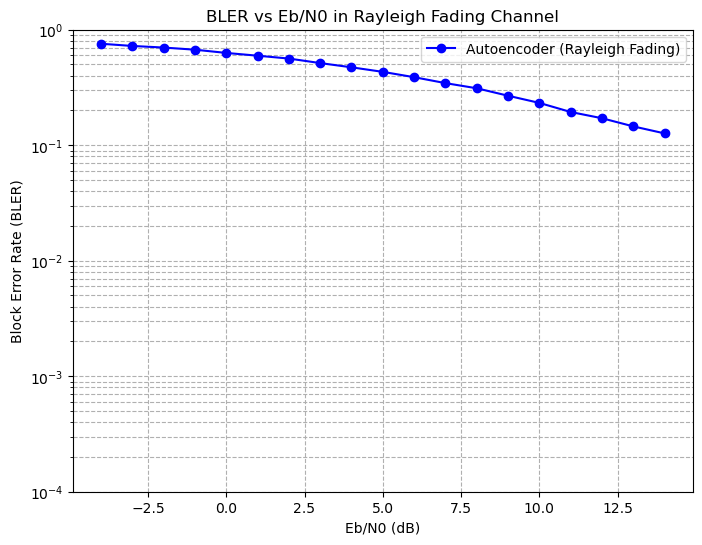

In [5]:
# Evaluate BLER vs Eb/N0
EbN0_dB_range = list(range(-4, 15))
bler_fading = []

k = np.log2(M)
R = k / n_dims

TEST_SAMPLES = 50000
test_labels = torch.randint(0, M, (TEST_SAMPLES,))
test_data_onehot = torch.nn.functional.one_hot(test_labels, num_classes=M).float().to(device)
test_labels = test_labels.to(device)

print("Evaluating BLER performance...")
model.eval()
with torch.no_grad():
    for EbN0_dB in EbN0_dB_range:
        EbN0_linear = 10**(EbN0_dB / 10.0)
        noise_var = 1.0 / (2 * R * EbN0_linear)
        
        outputs, _, _, _ = model(test_data_onehot, noise_var)
        predictions = torch.argmax(outputs, dim=1)
        errors = (predictions != test_labels).sum().item()
        bler = errors / TEST_SAMPLES
        bler_fading.append(bler)
        print(f"Eb/N0 (dB): {EbN0_dB:2d} | BLER: {bler:.5f}")

plt.figure(figsize=(8, 6))
plt.semilogy(EbN0_dB_range, bler_fading, 'bo-', label='Autoencoder (Rayleigh Fading)')
plt.grid(True, which="both", ls="--")
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Block Error Rate (BLER)')
plt.title('BLER vs Eb/N0 in Rayleigh Fading Channel')
plt.legend()
plt.ylim(1e-4, 1)
plt.show()
